In [135]:
import pandas as pd
import matplotlib.pyplot as plt

df_games = pd.read_csv("C:/Users/esteb/Documents/Esteban/CURSOS/Data-analisis-ComIT_ok/proyecto-final-data-analysis/data/steam_games_clean.csv")
df_copy = df_games.copy()

In [142]:
df_copy.isnull().sum()

app_id                      0
name                        0
release_date                0
price                       0
price_status                0
estimated_owners            0
developers                  0
publishers                  0
genres                      0
categories                  0
tags                        0
positive                    0
negative                    0
average_playtime_forever    0
median_playtime_forever     0
short_description           0
dlc_count                   0
new_app_id                  0
total_ratings               0
good_rating                 2
dtype: int64

In [136]:
df_games.estimated_owners.value_counts()

estimated_owners
20000 - 50000            11258
50000 - 100000            5290
100000 - 200000           3402
200000 - 500000           2801
500000 - 1000000          1124
1000000 - 2000000          704
2000000 - 5000000          393
5000000 - 10000000         119
10000000 - 20000000         49
20000000 - 50000000         29
50000000 - 100000000         7
100000000 - 200000000        4
Name: count, dtype: int64

In [143]:
#Se hace una copia del DB para ajustar la óptica de los registros más relevantes para el análisis de los juegos más exitosos y agilizar el tiempo de porcesamiento en el analisis. Se tomarán los registros con mas de 1.000.000 ventas, significando aproximadamente la mitad de la escala de la que se tienen registros.

df_copy["estimated_owners"] = df_copy.estimated_owners[df_copy.estimated_owners.isin(["1000000 - 2000000", "2000000 - 5000000", "5000000 - 10000000", "10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000", "100000000 - 200000000"])]

df_copy = df_copy.dropna(subset=["estimated_owners"])

In [144]:
#Creación de columnas de total rating y porcentaje positivo de reseñas.

df_copy["total_ratings"] = df_copy["positive"] + df_copy["negative"]

df_copy["good_rating"] = (((df_copy["positive"] - df_copy["negative"]) / df_copy["total_ratings"]) * 100).round(2)

In [145]:
#Prueba de columna Tags, que tiene la misma logica que genres y categories.

print(df_copy["tags"].head())

print(df_copy["tags"].tail())

26    ["Battle Royale", "Free to Play", "Multiplayer...
38    ["Multiplayer", "Funny", "Online Co-Op", "4 Pl...
40    ["Anime", "JRPG", "Action RPG", "Action", "Onl...
41    ["Physics", "Rogue-like", "Pixel Graphics", "D...
52    ["Strategy", "Turn-Based Tactics", "Turn-Based...
Name: tags, dtype: str
25171    {"Action": 1339, "FPS": 979, "Shooter": 723, "...
25172    {"FPS": 403, "Action": 295, "Classic": 237, "S...
25173    {"Animation & Modeling": 772, "Free to Play": ...
25174    {"RPG": 446, "First-Person": 388, "Action": 36...
25178    {"Atmospheric": 1466, "Post-apocalyptic": 1356...
Name: tags, dtype: str


In [ ]:
#Normalización de datos de la comlumna Tags, Genres y Categories. Al revisar las columnas podemos observar que algunos registros tienen forma de diccionario mientras que otros tienen forma de lista. Transformaremos todo para que sea uniforme a listas.

#En una primer instancia, intentamos pasar los registros que parecian ser dict a list, pero la funcion no se aplicaba correctamente porque aún teniendo forma de dict, en realidad solo eran str. Eliminaremos los numeros y los :, los {} y [] del string para poder procesar cada valor y su distribución de forma separada, agrupandolos en listas.

df_copy["tags"] = df_copy["tags"].str.replace(r"[0-9:\{\}\[\]\"]", "", regex=True).str.replace("description", "")
df_copy["tags"] = df_copy["tags"].str.split(",").apply(lambda lista: [x.strip().strip('"').strip("'") for x in lista])

df_copy["categories"] = df_copy["categories"].str.replace(r"[0-9:\{\}\[\]\"]", "", regex=True).str.replace("description", "")
df_copy["categories"] = df_copy["categories"].str.split(",").apply(lambda lista: [x.strip().strip('"').strip("'") for x in lista])

df_copy["genres"] = df_copy["genres"].str.replace(r"[0-9:\{\}\[\]\"]", "", regex=True).str.replace("description", "")
df_copy["genres"] = df_copy["genres"].str.split(",").apply(lambda lista: [x.strip().strip('"').strip("'") for x in lista])





In [148]:
#Catalogación por numero de ventas.

best_sellers = df_copy[df_copy.estimated_owners.isin(["10000000 - 20000000", "20000000 - 50000000", "50000000 - 100000000", "100000000 - 200000000", "50000000 - 100000000"])]

top_best_seller1 = df_copy[df_copy.estimated_owners == "100000000 - 200000000"]

top_best_seller2 = df_copy[df_copy.estimated_owners == "50000000 - 100000000"]



In [158]:
#Filtrado de los juegos más vendidos en relación al balance de puntuaciones de usuarios + valoraciones en nuevos lanzamientos.

loved_best_sellers = best_sellers[best_sellers.good_rating >= 90].sort_values(by="good_rating", ascending=False).head(10)

new_loved_best_sellers = loved_best_sellers[loved_best_sellers.release_date > "2021-01-01"]

In [159]:
#Caracteristicas de cada filtrado. Más popular, mas amado histórico y mejor desempeño en nuevo lanzamiento.

conteo_tags_new_lbs = new_loved_best_sellers["tags"].explode().value_counts()
conteo_cats_new_lbs = new_loved_best_sellers["categories"].explode().value_counts()
conteo_genres_new_lbs = new_loved_best_sellers["genres"].explode().value_counts()

conteo_tags_lbs = loved_best_sellers["tags"].explode().value_counts()
conteo_cats_lbs = loved_best_sellers["categories"].explode().value_counts()
conteo_genres_lbs = loved_best_sellers["genres"].explode().value_counts()

conteo_tags_topbs = top_best_seller1["tags"].explode().value_counts()
conteo_cats_topbs = top_best_seller1["categories"].explode().value_counts()
conteo_genres_topbs = top_best_seller1["genres"].explode().value_counts()


In [156]:
print(f"Caracteristicas de los juegos más populares histórico: \n {conteo_cats_topbs} \n {conteo_genres_topbs} \n {conteo_tags_topbs}")

Caracteristicas de los juegos más populares histórico: 
 categories
id                              40
Multi-player                     4
Steam Trading Cards              3
In-App Purchases                 3
Custom Volume Controls           3
PvP                              2
Online PvP                       2
Co-op                            2
Playable without Timed Input     2
Stereo Sound                     2
Surround Sound                   2
Stats                            2
Remote Play on Phone             2
Remote Play on Tablet            2
Steam Workshop                   2
Camera Comfort                   2
Color Alternatives               2
Valve Anti-Cheat enabled         2
Steam Timeline                   2
Online Co-op                     1
Steam Achievements               1
Full controller support          1
Chat Speech-to-text              1
Partial Controller Support       1
Family Sharing                   1
SteamVR Collectibles             1
Cross-Platform Multipl

Los 4 más populares históricos comparten: Multiplayer Online + PvP + Team-based/Co-op + Action + Free to Play.

In [160]:
print(f"Caracteristicas de los juegos más amados histórico: \n {conteo_cats_lbs} \n {conteo_genres_lbs} \n {conteo_tags_lbs}")

Caracteristicas de los juegos más amados histórico: 
 categories
id                              149
Family Sharing                    9
Single-player                     8
Steam Achievements                8
Custom Volume Controls            7
Stereo Sound                      7
Multi-player                      7
DualShock Controller Support      6
DualSense Controller Support      6
Remote Play on Phone              6
Remote Play on Tablet             6
Co-op                             6
Online Co-op                      6
Steam Trading Cards               6
Steam Cloud                       6
Full controller support           5
Camera Comfort                    5
Steam Workshop                    5
Save Anytime                      4
Steam Input API Support           4
Surround Sound                    4
Remote Play Together              4
Captions available                3
Includes level editor             3
Includes Source SDK               3
Commentary available              3

Para los más amados históricos, las características son más variadas. Podemos encontrar con mayor frecuencia:

 Action + Singleplayer & Multiplayer + Co-op & Online Co-op. 

In [161]:
print(f"Caracteristicas de los nuevos lanzamientos con mejor desempeño: \n {conteo_cats_new_lbs} \n {conteo_genres_new_lbs} \n {conteo_tags_new_lbs}")

Caracteristicas de los nuevos lanzamientos con mejor desempeño: 
 categories
Single-player                 2
Multi-player                  2
Co-op                         2
Online Co-op                  2
Custom Volume Controls        2
Stereo Sound                  2
Family Sharing                2
Steam Achievements            1
Adjustable Text Size          1
Camera Comfort                1
Save Anytime                  1
Steam Cloud                   1
Partial Controller Support    1
Name: count, dtype: int64 
 genres
Action          2
Indie           2
Early Access    2
Simulation      1
Strategy        1
Adventure       1
Name: count, dtype: int64 
 tags
Co-op                      2
First-Person               2
Action                     2
Early Access               2
Action-Adventure           2
Simulation                 1
Crime                      1
Multiplayer                1
Open World                 1
Management                 1
Crafting                   1
Base-Buildin

Nuevos Lanzamientos con mejor desempeño presentan en mayor porcentaje, aún siendo bastante variados: 

Action + SinglePlayer & Multiplayer + Co-op & Online Co-op. 

Tambien "Early-access" tiene una frecuencia en más de un juego del listado, lo que podría indicarnos que son juegos que son esperados, lo que pone mayor peso en el marketing y el "hype" que se puede generar en base al desarrollo del juego.

TOP MAS DESCARGADOS HISTORICO (+100M descargas)

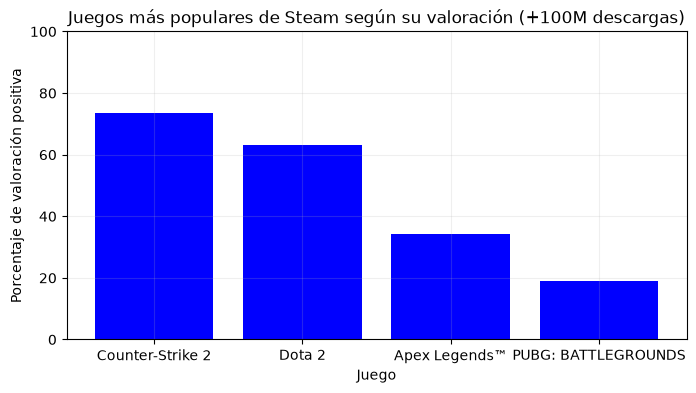

In [112]:
#Visualización juegos más populares segun su valoración positiva. ¿Qué juegos son los más populares historicamente?
top_best_seller1 = top_best_seller1.sort_values(by="good_rating", ascending=False)

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(top_best_seller1.name, top_best_seller1.good_rating, color="blue")
ax.set_title("Juegos más populares de Steam según su valoración (+100M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de valoración positiva")
ax.set_ylim(0, 100)
ax.grid(alpha=0.2)
plt.show()

TOP MEJOR VALORADOS HISTORICO (+10M descargas)

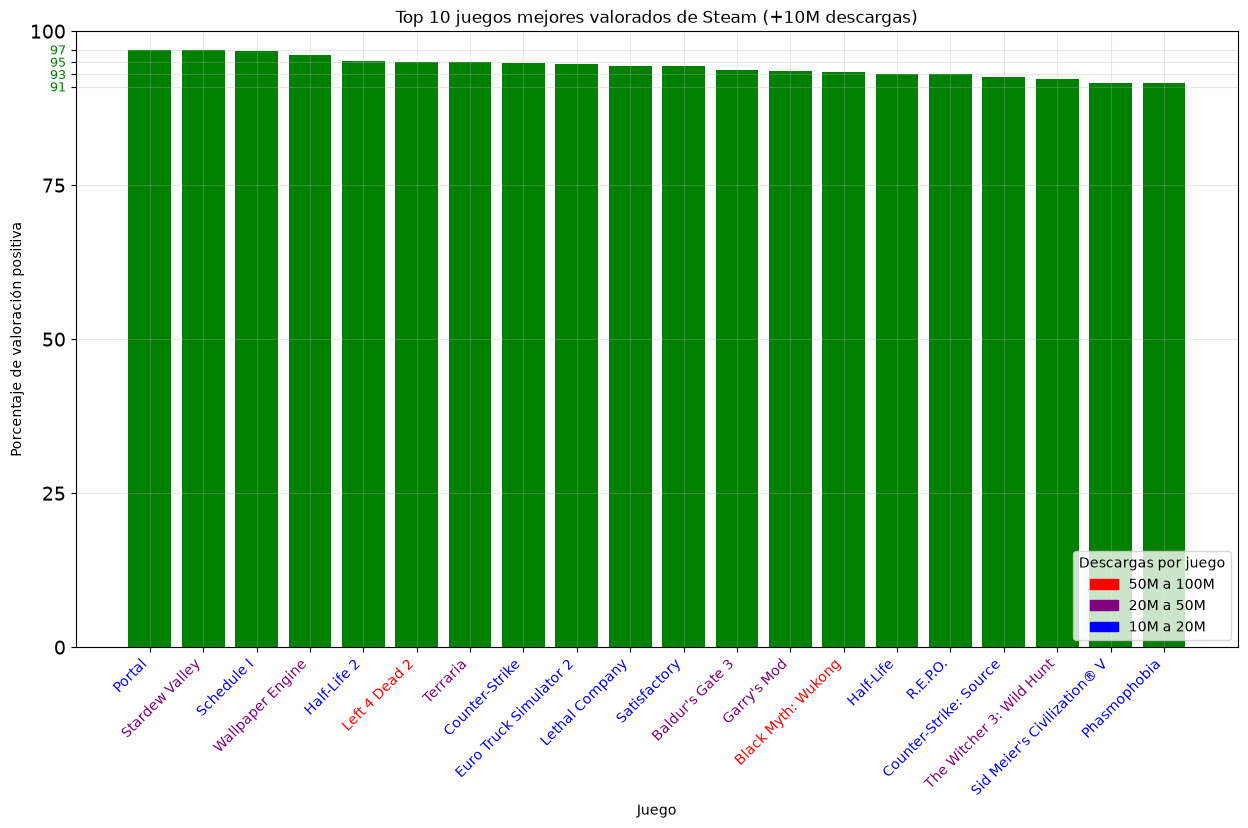

Cantidad de descargas de los jeugos mejor valorados: 
 
24773                         Portal 10000000 - 20000000
19349                 Stardew Valley 20000000 - 50000000
13197                     Schedule I 10000000 - 20000000
18734               Wallpaper Engine 20000000 - 50000000
24769                    Half-Life 2 10000000 - 20000000
24776                 Left 4 Dead 2 50000000 - 100000000
24037                       Terraria 20000000 - 50000000
24760                 Counter-Strike 10000000 - 20000000
24479         Euro Truck Simulator 2 10000000 - 20000000
9299                  Lethal Company 10000000 - 20000000
16793                   Satisfactory 10000000 - 20000000
1876                 Baldur's Gate 3 20000000 - 50000000
24875                    Garry's Mod 20000000 - 50000000
11151            Black Myth: Wukong 50000000 - 100000000
24766                      Half-Life 10000000 - 20000000
13321                       R.E.P.O. 10000000 - 20000000
24770         Counter-Strike: So

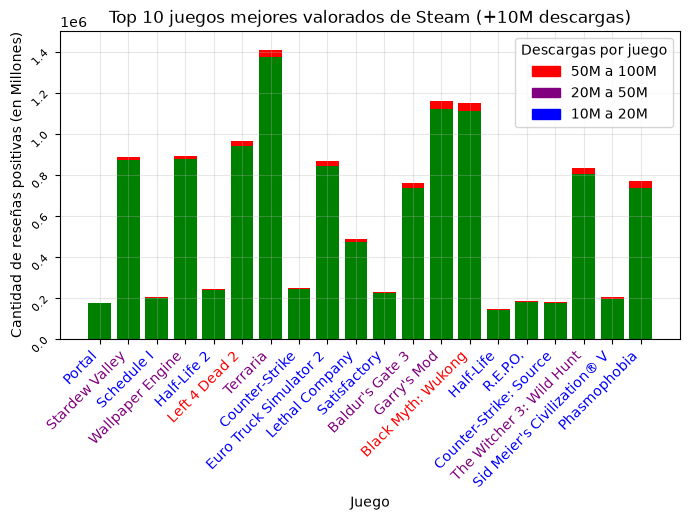

In [133]:
#Visualización juegos mejores valorados con más de 10M descargas según valoración. ¿Que juegos son los más gustados históricamentes?
import matplotlib.patches as mpatches
loved_best_sellers_grph = loved_best_sellers.sort_values(by="good_rating", ascending=False).head(20)

fig, ax = plt.subplots(figsize = (15,8))
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.good_rating, color="green")
ax.set_title("Top 10 juegos mejores valorados de Steam (+10M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de valoración positiva")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)

ax.set_yticks([0,25,50,75,91, 93, 95, 97, 100])
plt.xticks(rotation=45, ha="right")

for label in ax.get_yticklabels():
    if label.get_text() >= "90":
        label.set_fontsize(9)
        label.set_color("green")
    else:
        label.set_fontsize(14)

for label in ax.get_xticklabels():
    texto = label.get_text()
    descargas = df_copy.loc[df_copy["name"] == texto, "estimated_owners"].values[0]

    if descargas == "50000000 - 100000000":
        label.set_color("red")
    elif descargas == "100000000 - 200000000":
        label.set_color("orange")
    elif descargas == "20000000 - 50000000":
        label.set_color("purple")
    elif descargas == "10000000 - 20000000":
        label.set_color("blue")
    else:
        label.set_color("black")

rojo = mpatches.Patch(color="red", label="50M a 100M")
azul = mpatches.Patch(color="blue", label="10M a 20M")
violeta = mpatches.Patch(color="purple", label="20M a 50M")

ax.legend(handles=[rojo, violeta,azul], title = "Descargas por juego", loc="lower right")

plt.show()

print(f"Cantidad de descargas de los jeugos mejor valorados: \n \n{loved_best_sellers_grph.name +" "+ loved_best_sellers_grph.estimated_owners}")


#Segun cantidad neta de valoración positiva.

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.positive, color="green",label="positivas")
ax.bar(loved_best_sellers_grph.name, loved_best_sellers_grph.negative, bottom= loved_best_sellers_grph.positive, color="red", label="negativas")
ax.set_title("Top 10 juegos mejores valorados de Steam (+10M descargas)")
ax.set_xlabel("Juego")
ax.set_ylabel("Cantidad de reseñas positivas (en Millones)")
ax.set_ylim(0, 1500000)
ax.grid(alpha=0.3)


plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=45, ha="right", fontsize=8)

for label in ax.get_xticklabels():
    texto = label.get_text()
    descargas = df_copy.loc[df_copy["name"] == texto, "estimated_owners"].values[0]

    if descargas == "50000000 - 100000000":
        label.set_color("red")
    elif descargas == "100000000 - 200000000":
        label.set_color("orange")
    elif descargas == "20000000 - 50000000":
        label.set_color("purple")
    elif descargas == "10000000 - 20000000":
        label.set_color("blue")
    else:
        label.set_color("black")

rojo = mpatches.Patch(color="red", label="50M a 100M")
azul = mpatches.Patch(color="blue", label="10M a 20M")
violeta = mpatches.Patch(color="purple", label="20M a 50M")

ax.legend(handles=[rojo, violeta,azul], title = "Descargas por juego")

plt.show()


In [130]:
df_copy["positive"].max()

np.int64(7642084)

NUEVOS LANZAMIENTOS EXITOSOS (Valoracion positiva + +10M descargas)

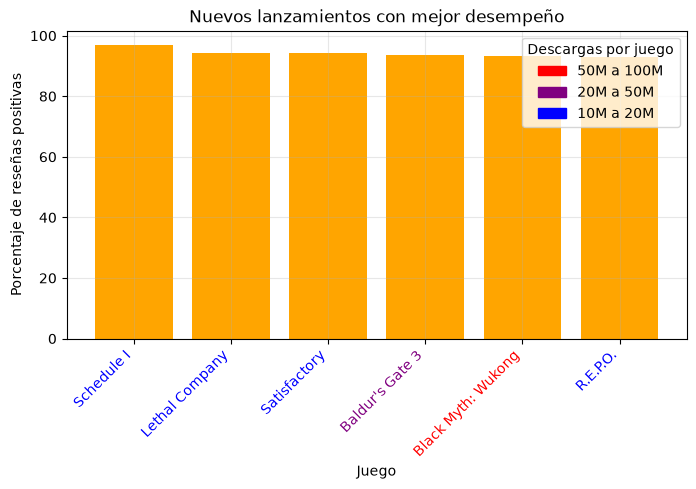

 Nuevos lanzamientos con mejor desempeño: 
 13197            Schedule I
9299         Lethal Company
16793          Satisfactory
1876        Baldur's Gate 3
11151    Black Myth: Wukong
13321              R.E.P.O.
Name: name, dtype: str 13197    2025-03-24
9299     2023-10-23
16793    2024-09-10
1876     2023-08-03
11151    2024-08-19
13321    2025-02-26
Name: release_date, dtype: str 13197     10000000 - 20000000
9299      10000000 - 20000000
16793     10000000 - 20000000
1876      20000000 - 50000000
11151    50000000 - 100000000
13321     10000000 - 20000000
Name: estimated_owners, dtype: str 13197    96.83
9299     94.36
16793    94.32
1876     93.70
11151    93.33
13321    93.01
Name: good_rating, dtype: float64


In [117]:
#Visualización de juegos nuevos, lanzados a partir de 2022 que alcanzaron el exito en ventas y buenas puntuaciones. ¿Que juegos recientes tuvieron éxito en el mercado actual?

new_loved_best_sellers_grph = new_loved_best_sellers.sort_values(by="good_rating", ascending=False)

fig, ax = plt.subplots(figsize = (8,4))
ax.bar(new_loved_best_sellers_grph.name, new_loved_best_sellers_grph.good_rating, color="orange")
ax.set_title("Nuevos lanzamientos con mejor desempeño")
ax.set_xlabel("Juego")
ax.set_ylabel("Porcentaje de reseñas positivas")
ax.grid(alpha=0.3)

for label in ax.get_xticklabels():
    texto = label.get_text()
    descargas = df_copy.loc[df_copy["name"] == texto, "estimated_owners"].values[0]

    if descargas == "50000000 - 100000000":
        label.set_color("red")
    elif descargas == "100000000 - 200000000":
        label.set_color("orange")
    elif descargas == "20000000 - 50000000":
        label.set_color("purple")
    elif descargas == "10000000 - 20000000":
        label.set_color("blue")
    else:
        label.set_color("black")

rojo = mpatches.Patch(color="red", label="50M a 100M")
azul = mpatches.Patch(color="blue", label="10M a 20M")
violeta = mpatches.Patch(color="purple", label="20M a 50M")

ax.legend(handles=[rojo, violeta,azul], title = "Descargas por juego")

plt.xticks(rotation=45, ha="right")

plt.show()

print(f" Nuevos lanzamientos con mejor desempeño: \n {new_loved_best_sellers_grph.name} {new_loved_best_sellers_grph.release_date} {new_loved_best_sellers_grph.estimated_owners} {new_loved_best_sellers_grph.good_rating}")

A PARTIR DE ACA

In [64]:
#Me falta stacked bars para comparativa negative vs positive en top 10 históricos. Asi se ve en contexto cuantas reseñas hay por cada uno.

#Analizar tags y genres de juegos + populares(que da masividad), mejores valorados históricos(que funciona historicamente) y nuevos lanzamientos(que funciona ahora).

Características de los juegos más populares histórico, más amados histórico y mejor desempeño actual.

In [80]:
print(f" Las caracteristicas de los juegos con mejor desempeño actual son: \n Categorias: \n {new_loved_best_sellers["categories"].explode().value_counts().head(10)} \n Generos: \n {new_loved_best_sellers["genres"].explode().value_counts().head(10)} \n Tags: \n {new_loved_best_sellers["tags"].explode().value_counts().head(10)}")

 Las caracteristicas de los juegos con mejor desempeño actual son: 
 Categorias: 
 categories
id                        23
Single-player              5
Stereo Sound               5
Family Sharing             5
Multi-player               4
Co-op                      4
Online Co-op               4
Custom Volume Controls     4
Steam Cloud                4
Steam Achievements         3
Name: count, dtype: int64 
 Generos: 
 genres
Action          4
Adventure       4
id              4
Indie           3
Strategy        3
Early Access    3
Simulation      2
RPG             2
Name: count, dtype: int64 
 Tags: 
 tags
Co-op               4
Multiplayer         4
First-Person        4
Action              4
Early Access        4
Adventure           4
Strategy            3
Action-Adventure    3
Online Co-Op        3
Exploration         3
Name: count, dtype: int64


In [134]:
print(f" Las caracteristicas de los juegos más descargados históricos son: \n Categorias: \n {top_best_seller1["categories"].explode().value_counts().head(10)} \n Generos: \n {top_best_seller1["genres"].explode().value_counts().head(10)} \n Tags: \n {top_best_seller1["tags"].explode().value_counts().head(10)}")

 Las caracteristicas de los juegos más descargados históricos son: 
 Categorias: 
 categories
id                              40
Multi-player                     4
Steam Trading Cards              3
In-App Purchases                 3
Custom Volume Controls           3
Steam Workshop                   2
Camera Comfort                   2
Color Alternatives               2
Playable without Timed Input     2
Stereo Sound                     2
Name: count, dtype: int64 
 Generos: 
 genres
id                       9
Action                   4
Free To Play             4
Adventure                2
Strategy                 1
Massively Multiplayer    1
Name: count, dtype: int64 
 Tags: 
 tags
Multiplayer     4
Action          4
Team-Based      4
PvP             4
Co-op           4
FPS             3
Shooter         3
Competitive     3
Tactical        3
First-Person    3
Name: count, dtype: int64


In [46]:
print(f" Las caracteristicas de los juegos más amados históricos son: \n Categorias: \n {loved_best_sellers["categories"].explode().value_counts().head(10)} \n Generos: \n {loved_best_sellers["genres"].explode().value_counts().head(10)} \n Tags: \n {loved_best_sellers["tags"].explode().value_counts().head(10)}")

 Las caracteristicas de los juegos más amados históricos son: 
 Categorias: 
 categories
id                                          344
description Family Sharing                   18
description Single-player                    16
description Steam Achievements               15
description Remote Play on Tablet            15
description Steam Cloud                      15
description DualShock Controller Support     14
description DualSense Controller Support     14
description Multi-player                     14
description Steam Trading Cards              13
Name: count, dtype: int64 
 Generos: 
 genres
id                        48
description Action        12
description Indie          9
description Simulation     6
description Adventure      6
description RPG            5
Action                     4
Early Access               3
Adventure                  3
description Strategy       3
Name: count, dtype: int64 
 Tags: 
 Series([], Name: count, dtype: int64)


In [50]:
df_copy["genres"].tail()

25171                             [id, description Action]
25172                             [id, description Action]
25173    [id, description Animation & Modeling, id, des...
25174        [id, description Action, id, description RPG]
25178        [id, description Action, id, description RPG]
Name: genres, dtype: object